In [ ]:
# Importa bibliotecas necessárias.
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# Upload da imagem.
arquivo = files.upload()

Saving paisagem.jpeg to paisagem.jpeg


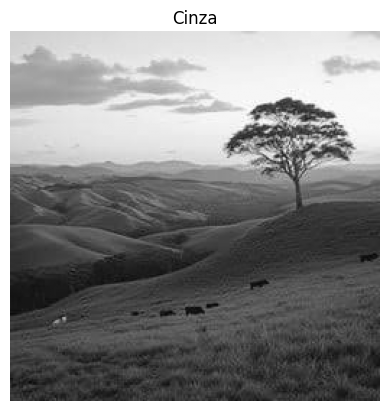

In [ ]:
# Lê a imagem e converte para tons de cinza.
img_bgr = cv2.imread('paisagem.jpeg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Exibe a imagem em tons de cinza.
plt.imshow(img_gray, cmap='gray')
plt.title('Cinza')
plt.axis('off')
plt.show()

In [ ]:
# Função para quantizar uma imagem para N bits.
def quantize_image(image, num_bits):
    if num_bits == 8:
        return image.copy() # 8 bits é a resolução original

    num_levels = 2**num_bits
    # Garante que num_levels seja pelo menos 2.
    if num_levels == 1:
        # Para 1 nível, mapeia tudo para preto.
        return np.zeros_like(image)

    # Normaliza, escala, arredonda e retorna para 0-255.
    quantized_image = np.round((image / 255.0) * (num_levels - 1)) * (255.0 / (num_levels - 1))
    return quantized_image.astype(np.uint8)

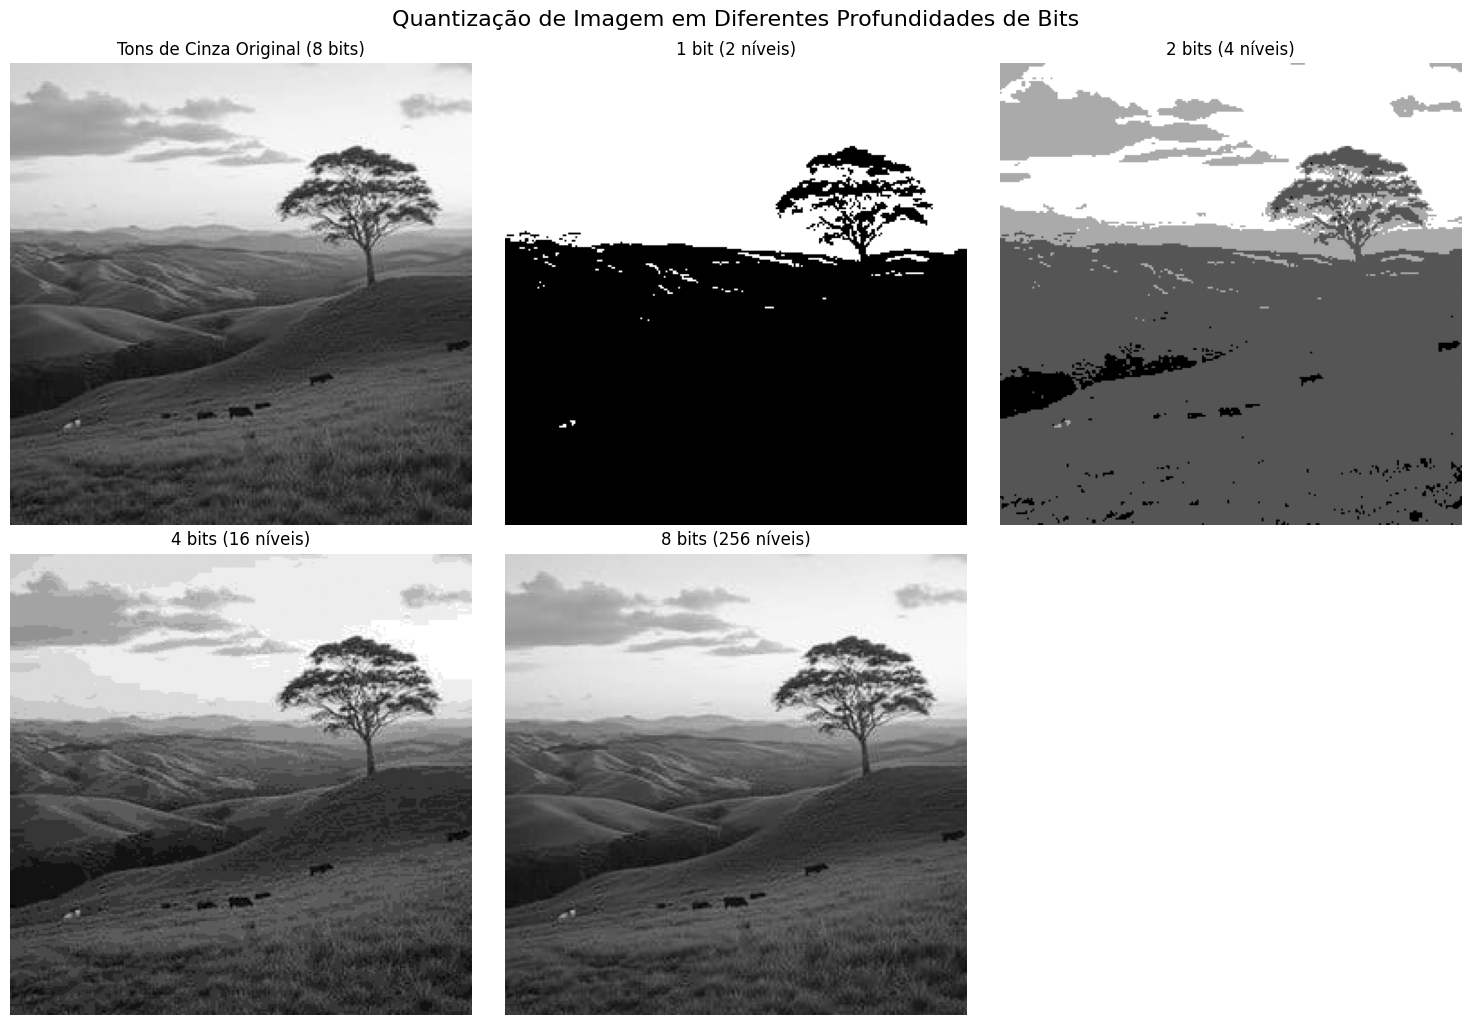

In [ ]:
# Quantiza para 1, 2, 4 e 8 bits.
img_1bit = quantize_image(img_gray, 1)
img_2bit = quantize_image(img_gray, 2)
img_4bit = quantize_image(img_gray, 4)
img_8bit = quantize_image(img_gray, 8)

# Cria a figura para exibição.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() # Achata os eixos para iteração.

# Lista de imagens e seus títulos.
images = [
    (img_gray, 'Tons de Cinza Original (8 bits)'),
    (img_1bit, '1 bit (2 níveis)'),
    (img_2bit, '2 bits (4 níveis)'),
    (img_4bit, '4 bits (16 níveis)'),
    (img_8bit, '8 bits (256 níveis)')
]

# Plota cada imagem.
for i, (image, title) in enumerate(images):
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(title)
    axes[i].axis('off') # Oculta os eixos.

# Oculta subplots não utilizados.
if len(images) < len(axes):
    for j in range(len(images), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout() # Ajusta o layout.
plt.suptitle('Quantização de Imagem em Diferentes Profundidades de Bits', y=1.02, fontsize=16) # Adiciona título principal.
plt.show()

# Salva a figura.
fig.savefig('quantizacao.png', bbox_inches='tight')

### Análise da Quantização

À medida que o número de bits utilizados para representar cada pixel é reduzido:

*   **Detalhes:** A imagem perde progressivamente os seus detalhes finos. Com menos níveis de intensidade, as pequenas variações tonais que contribuem para a riqueza dos detalhes são eliminadas, resultando em uma imagem mais 'chapada' ou blocada.

*   **Transições de Intensidade:** As transições suaves de intensidade (gradientes) tornam-se mais abruptas e visíveis. Em vez de uma mudança contínua de um tom para outro, observam-se 'degraus' distintos, um fenômeno conhecido como **contorno falso** (false contouring). Isso ocorre porque muitos tons originais são mapeados para o mesmo nível de intensidade quantizado, criando fronteiras claras onde antes havia uma gradação suave.

Em resumo, reduzir o número de bits leva a uma diminuição na qualidade visual da imagem, com perda de detalhes e transições de cor ou tom mais ásperas, mas também reduz o tamanho do arquivo da imagem.